In [12]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, auc

In [13]:
Roll_no=np.arange(1,51)
hours=[]
cgpa=[]
placed=[]
name=["Amit","Vansh","Ansh","Kavya","Anita"]*10
for i in range(50):
    a=np.random.randint(3,12)
    b=np.random.randint(6,9.8)
    c=np.random.choice([0,1])
    hours.append(a)
    cgpa.append(b)
    placed.append(c)
n=np.array((Roll_no,name,hours,cgpa,placed))
f=np.transpose(n)
df=pd.DataFrame(f,columns=("Roll_no","Name","Hours","CGPA","Placed"))
df
    

,Roll_no,Name,Hours,CGPA,Placed
0,1,Amit,8,7,1
1,2,Vansh,10,8,1
2,3,Ansh,6,8,1
3,4,Kavya,7,8,1
4,5,Anita,3,8,0
5,6,Amit,4,7,0
6,7,Vansh,10,8,1
7,8,Ansh,11,6,1
8,9,Kavya,8,8,0
9,10,Anita,7,7,1


In [14]:
X=df[["CGPA","Hours"]]
Y=df["Placed"]

In [15]:
model = SVC(kernel='linear')
model.fit(X, Y)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [17]:
y_pred=model.predict(X)
y_pred

array(['0', '1', '0', '0', '0', '0', '1', '1', '1', '0', '0', '0', '0',
       '1', '0', '0', '0', '1', '0', '1', '0', '0', '0', '0', '0', '0',
       '0', '1', '0', '0', '1', '1', '0', '1', '1', '0', '0', '0', '0',
       '1', '0', '0', '1', '0', '0', '0', '0', '1', '1', '1'],
      dtype=object)

In [18]:
new_points = np.array([[4, 6.5], [9, 8.8]])
new_preds = model.predict(new_points)
new_preds

C:\Users\rudra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['0', '1'], dtype=object)

In [20]:
print(f"Accuracy Score: {accuracy_score(Y, y_pred)}")


Accuracy Score: 0.6


In [21]:
print("Confusion Matrix:\n", confusion_matrix(Y, y_pred))
print("\nClassification Report:\n", classification_report(Y, y_pred))

Confusion Matrix:
 [[22  9]
 [11  8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69        31
           1       0.47      0.42      0.44        19

    accuracy                           0.60        50
   macro avg       0.57      0.57      0.57        50
weighted avg       0.59      0.60      0.60        50



In [22]:
w = model.coef_[0]
b = model.intercept_[0]

print("\nWeight (w):", w)
print("Bias (b):", b)


Weight (w): [0.42808922 0.28571429]
Bias (b): -5.567811974415672


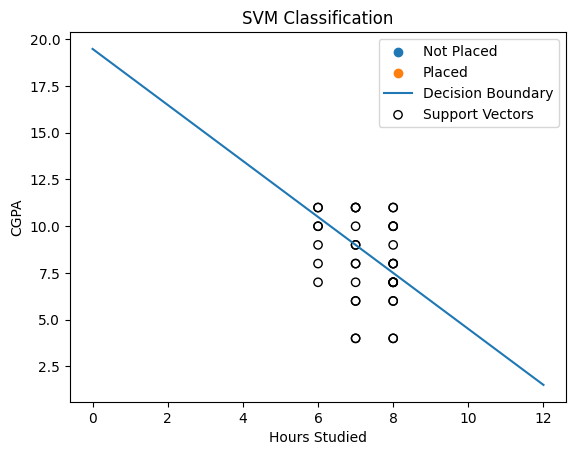

In [24]:
plt.scatter(X[Y==0]["Hours"], X[Y==0]["CGPA"], label="Not Placed")
plt.scatter(X[Y==1]["Hours"], X[Y==1]["CGPA"], label="Placed")
x_values = np.linspace(0, 12, 100)
y_values = -(w[0]*x_values + b) / w[1]
plt.plot(x_values, y_values, label="Decision Boundary")
sv = model.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='black', label="Support Vectors")
plt.xlabel("Hours Studied")
plt.ylabel("CGPA")
plt.title("SVM Classification")
plt.legend()
plt.show()